<a href="https://colab.research.google.com/github/Orange314159/IndependentStudyComputerScience/blob/main/QuantumPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Coding Practice

First install packages that are needed using pip. I am running this code in Google Colab so I will include this in my code so every time it runs it ensures that the computer I am using has all of the same packages that are needed.

In [ ]:
%pip install -q qiskit qiskit-aer matplotlib pylatexenc ## use -q because I don't need all the extra information about downloads

In [2]:
from qiskit import QuantumCircuit ## for the circuit
from qiskit_aer import AerSimulator ## so I can simulate on a classical computer
from qiskit.visualization import plot_histogram ## so I can see the graphs

In [3]:
qc = QuantumCircuit(2,2) ## base quantum circuit with 2 quantum bits and 2 classical bits

qc.h(0)     ## split qubit 0 to a equal prob of a 1 or a 0 dirac: |+>
qc.cx(0, 1) ## add a CNOT gate to the circuit where 0 is the control qubit and 1 is the target qubit

qc.measure([0,1], [0,1]) ## measure the qubits into the classical bits

simulator = AerSimulator()    ## init the classical simulator
job = simulator.run(qc, shots=1024) ## run the circuit with the simulator 1024 times to get a good average
result = job.result()         ## get the result of all of these runs to then plot

counts = result.get_counts()  ## the number of each state that was measured
print(f"Results: {counts}")   ## print out in readable format

Results: {'11': 540, '00': 484}


As we can see, we get a near even split of |00> and |11>. This should make sense because we entangled qubit 1 with qubit 0 using the CNOT gate.

Ok, now for a more complex example. Consider grover's algorithm with 10 qubits.

In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import math

n = 10 ## we will be using 10 qubits for a simple example
qc = QuantumCircuit(n) ## make a new quantum circuit with 10 qubits

qc.h(range(n))
qc.barrier()

itterations = int(3.14159 / 4  * math.sqrt(2**n)) ## equation for the optimal number of itterations for a 10 qubit simulation

for i in range(itterations):
  qc.h(n-1) ## start by setting each qubit to a |+>
  qc.mcx(list(range(n-1)), n-1) ## implement a multi controlled x gate this means that if all of the control gates are a 1 then it will apply pauli-x to target
  qc.h(n-1) ## apply hadamard gates again

  qc.barrier() ## we want to force the compiler here to not make optimizations across this

  ## create diffuser
  qc.h(range(n))
  qc.x(range(n))

  qc.h(n-1)
  qc.mcx(list(range(n-1)), n-1)
  qc.h(n-1)

  qc.x(range(n))
  qc.h(range(n))
  qc.barrier()

qc.measure_all()

Now we need to simulate this using AER.

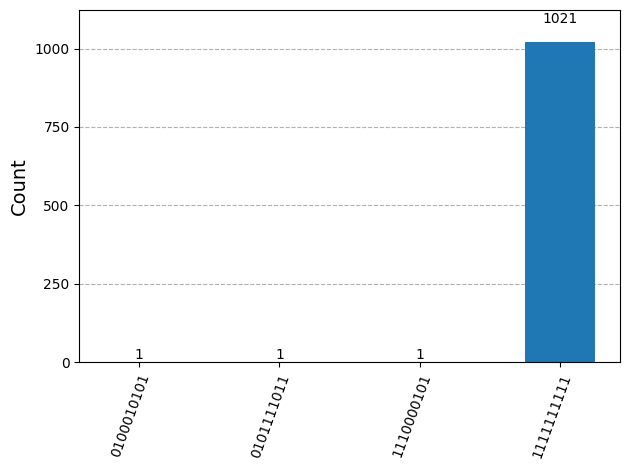

In [5]:
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

top_5 = dict(sorted(counts.items(), key= lambda x: x[1], reverse = True)[:5]) ## a little bit of code to get the top five results out of all results
plot_histogram(top_5)

Ok, but it would also be cool to look at the oracle finding a different number. Let's try 1010101010.

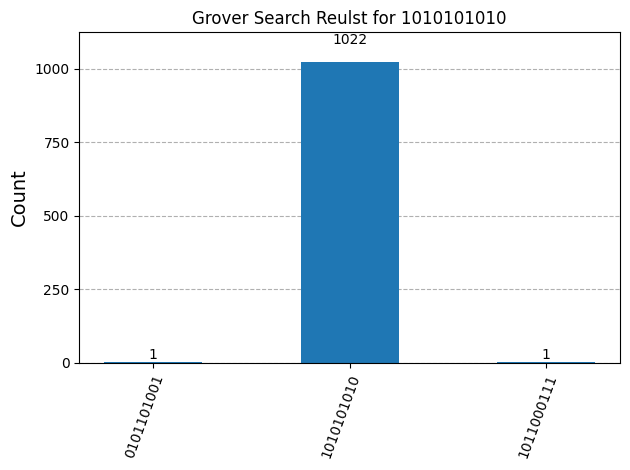

In [6]:
## use the same n as before

target = "1010101010"
qc = QuantumCircuit(n)

qc.h(range(n))
qc.barrier()

## use the same itterations as before

for i in range(itterations):
  for bit_index, bit in enumerate(reversed(target)):
    if bit == '0':
      qc.x(bit_index)

  qc.h(n-1)
  qc.mcx(list(range(n-1)), n-1)
  qc.h(n-1)

  for bit_index, bit in enumerate(reversed(target)):
    if bit == '0':
      qc.x(bit_index)

  qc.barrier()

  qc.h(range(n))
  qc.x(range(n))

  qc.h(n-1)
  qc.mcx(list(range(n-1)), n-1)
  qc.h(n-1)

  qc.x(range(n))
  qc.h(range(n))

  qc.barrier()

qc.measure_all()

## use same sim as before
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts, title=f"Grover Search Reulst for {target}")

Very cool, but with all of this code we might get lost from what is actually happening. Let's look at a visualization of the circuit.

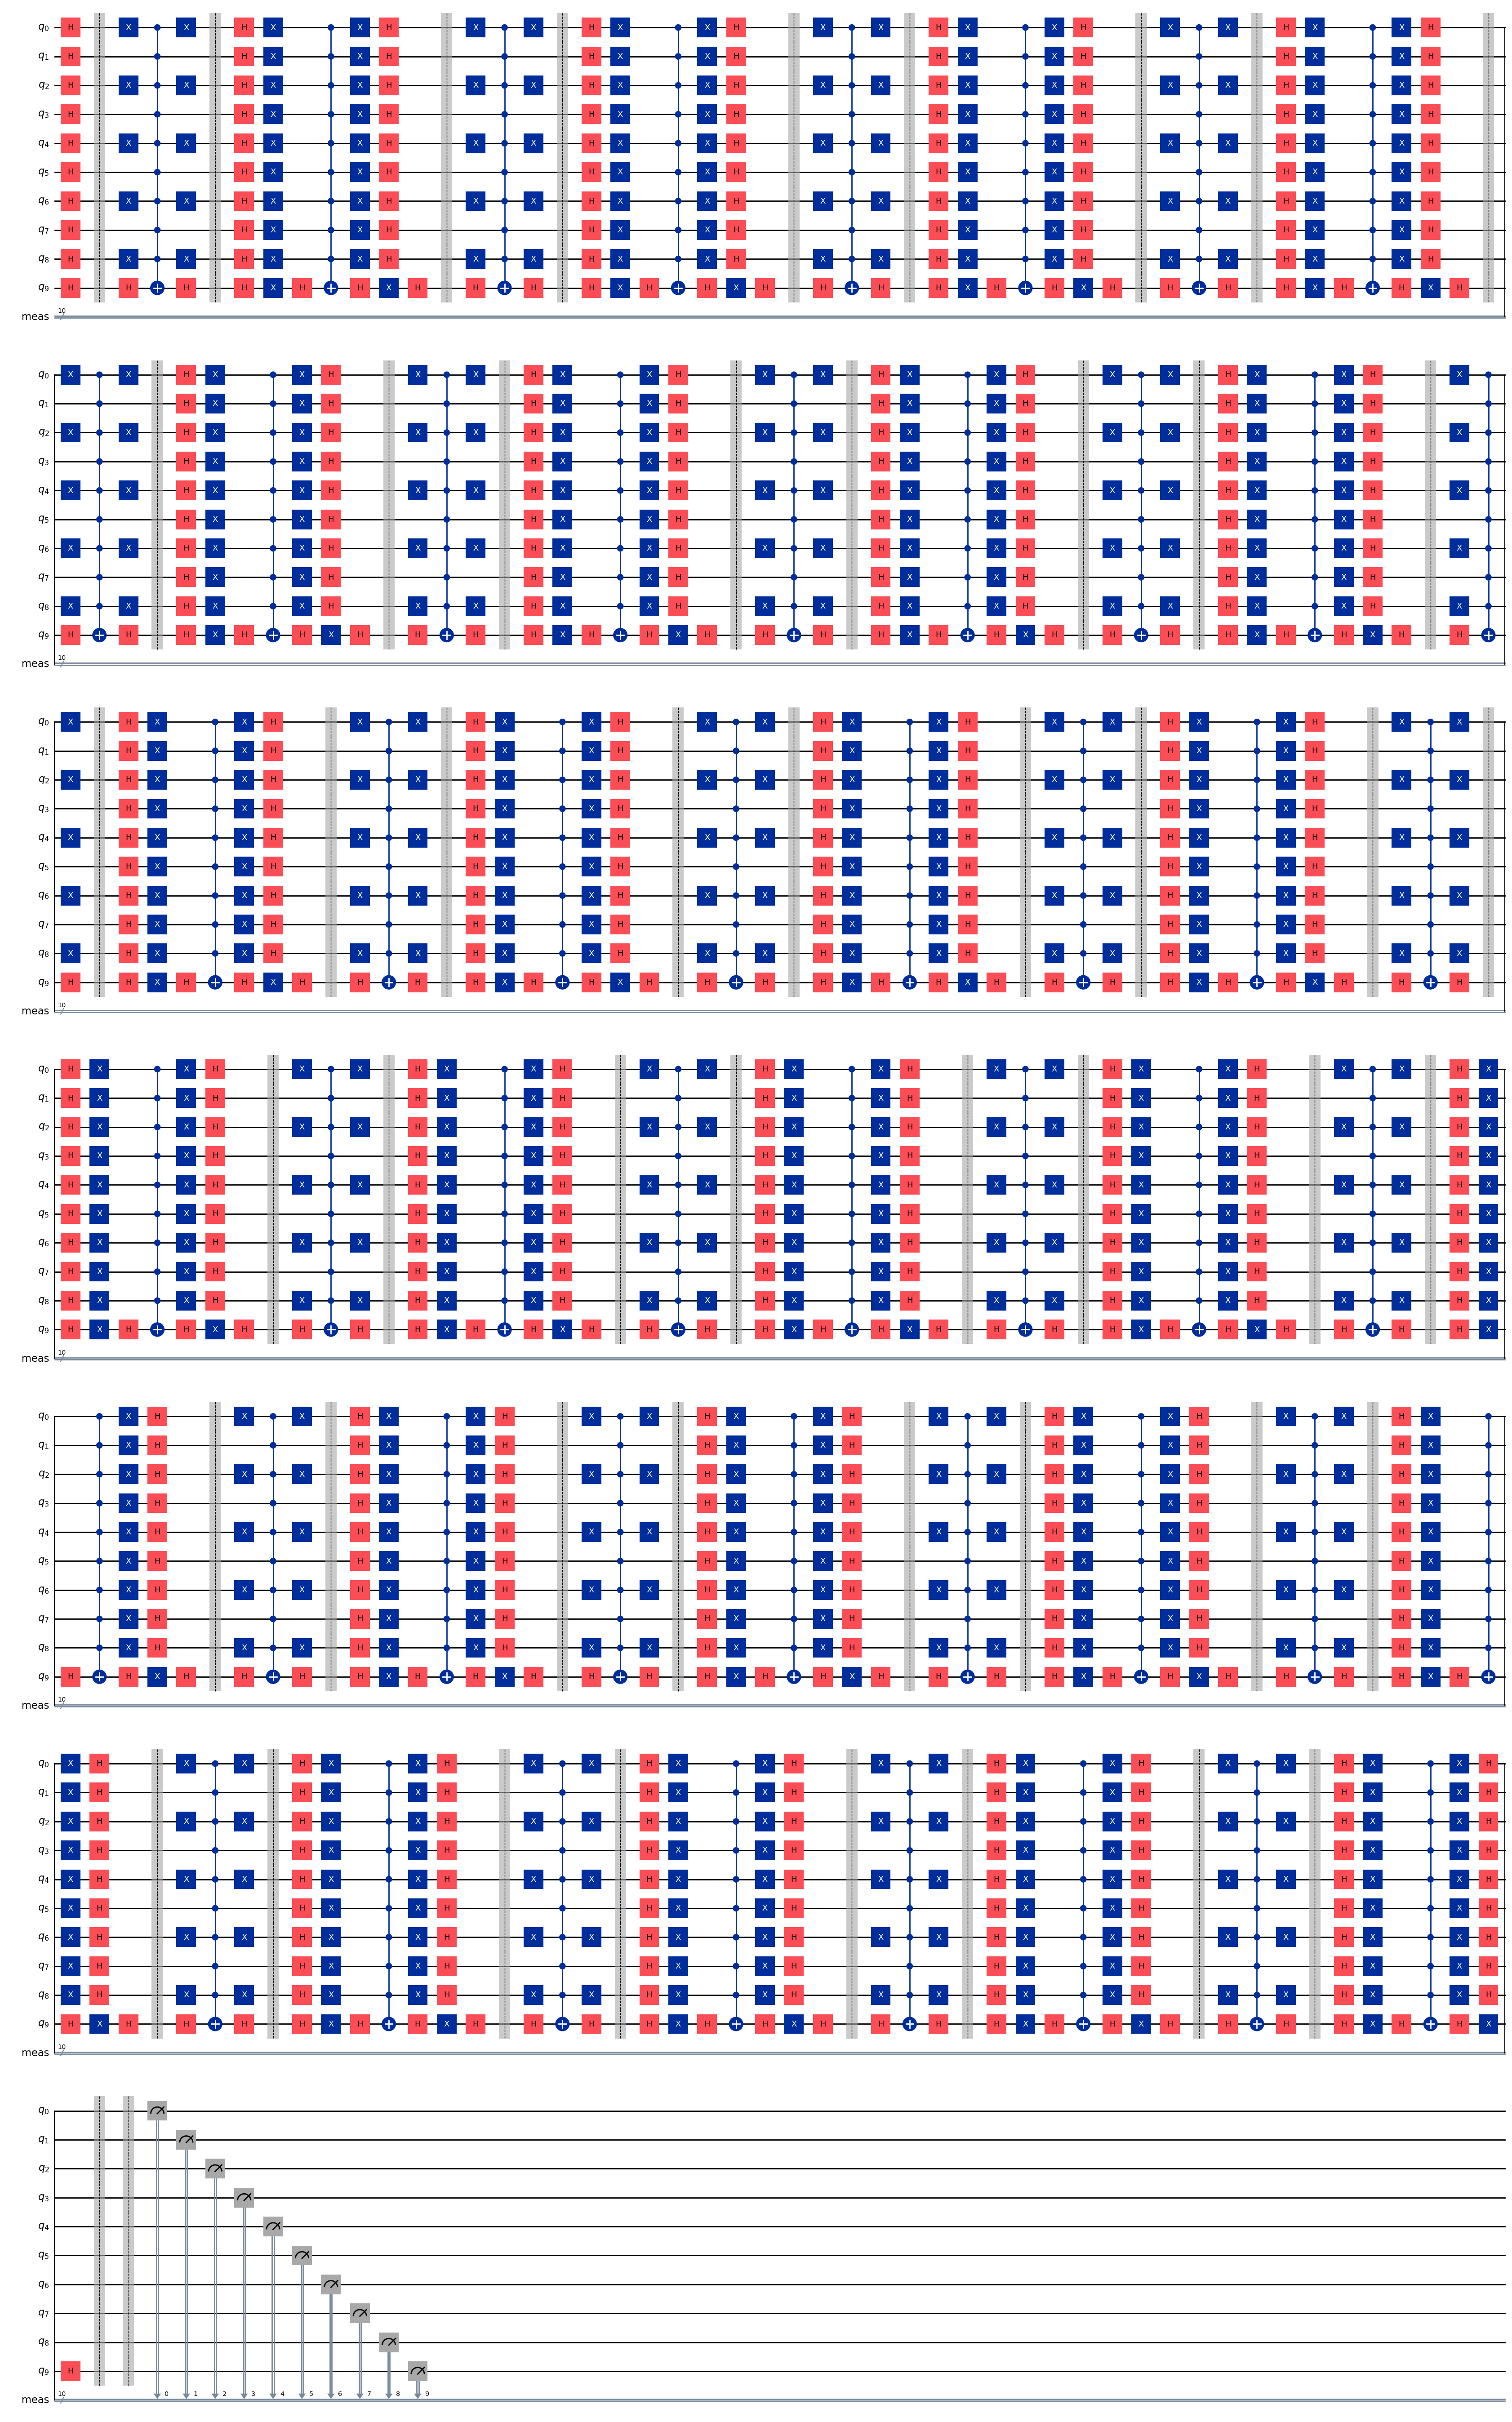

In [7]:
qc.draw('mpl', fold=50)

That looks super cool, but is not the most readable by compressing those repeated sections into blocks. In most textbooks we see that form of circuit so that's what we will do next, but I thought it was important to see the full thing first.

In [8]:
## continue with the same n and same target

oracle_cicruit = QuantumCircuit(n, name=" Oracle ") ## creating a gate for the oracle
## same process as before
for bit_index, bit in enumerate(reversed(target)):
  if bit == '0':
    oracle_cicruit.x(bit_index)
oracle_cicruit.h(n-1)
oracle_cicruit.mcx(list(range(n-1)), n-1)
oracle_cicruit.h(n-1)

for bit_index, bit in enumerate(reversed(target)):
  if bit == '0':
    oracle_cicruit.x(bit_index)

oracle_gate = oracle_cicruit.to_gate()

diffuser_circuit = QuantumCircuit(n, name=" Diffuser ") ## creating a gate for the diffuser
diffuser_circuit.h(range(n))
diffuser_circuit.x(range(n))
diffuser_circuit.h(n-1)
diffuser_circuit.mcx(list(range(n-1)), n-1)
diffuser_circuit.h(n-1)
diffuser_circuit.x(range(n))
diffuser_circuit.h(range(n))

diffuser_gate = diffuser_circuit.to_gate()

qc = QuantumCircuit(n)
qc.h(range(n))
qc.barrier()

## continue with the same itterations

for _ in range(itterations):
  qc.append(oracle_gate, range(n))
  qc.append(diffuser_gate, range(n))
  qc.barrier()


qc.measure_all()

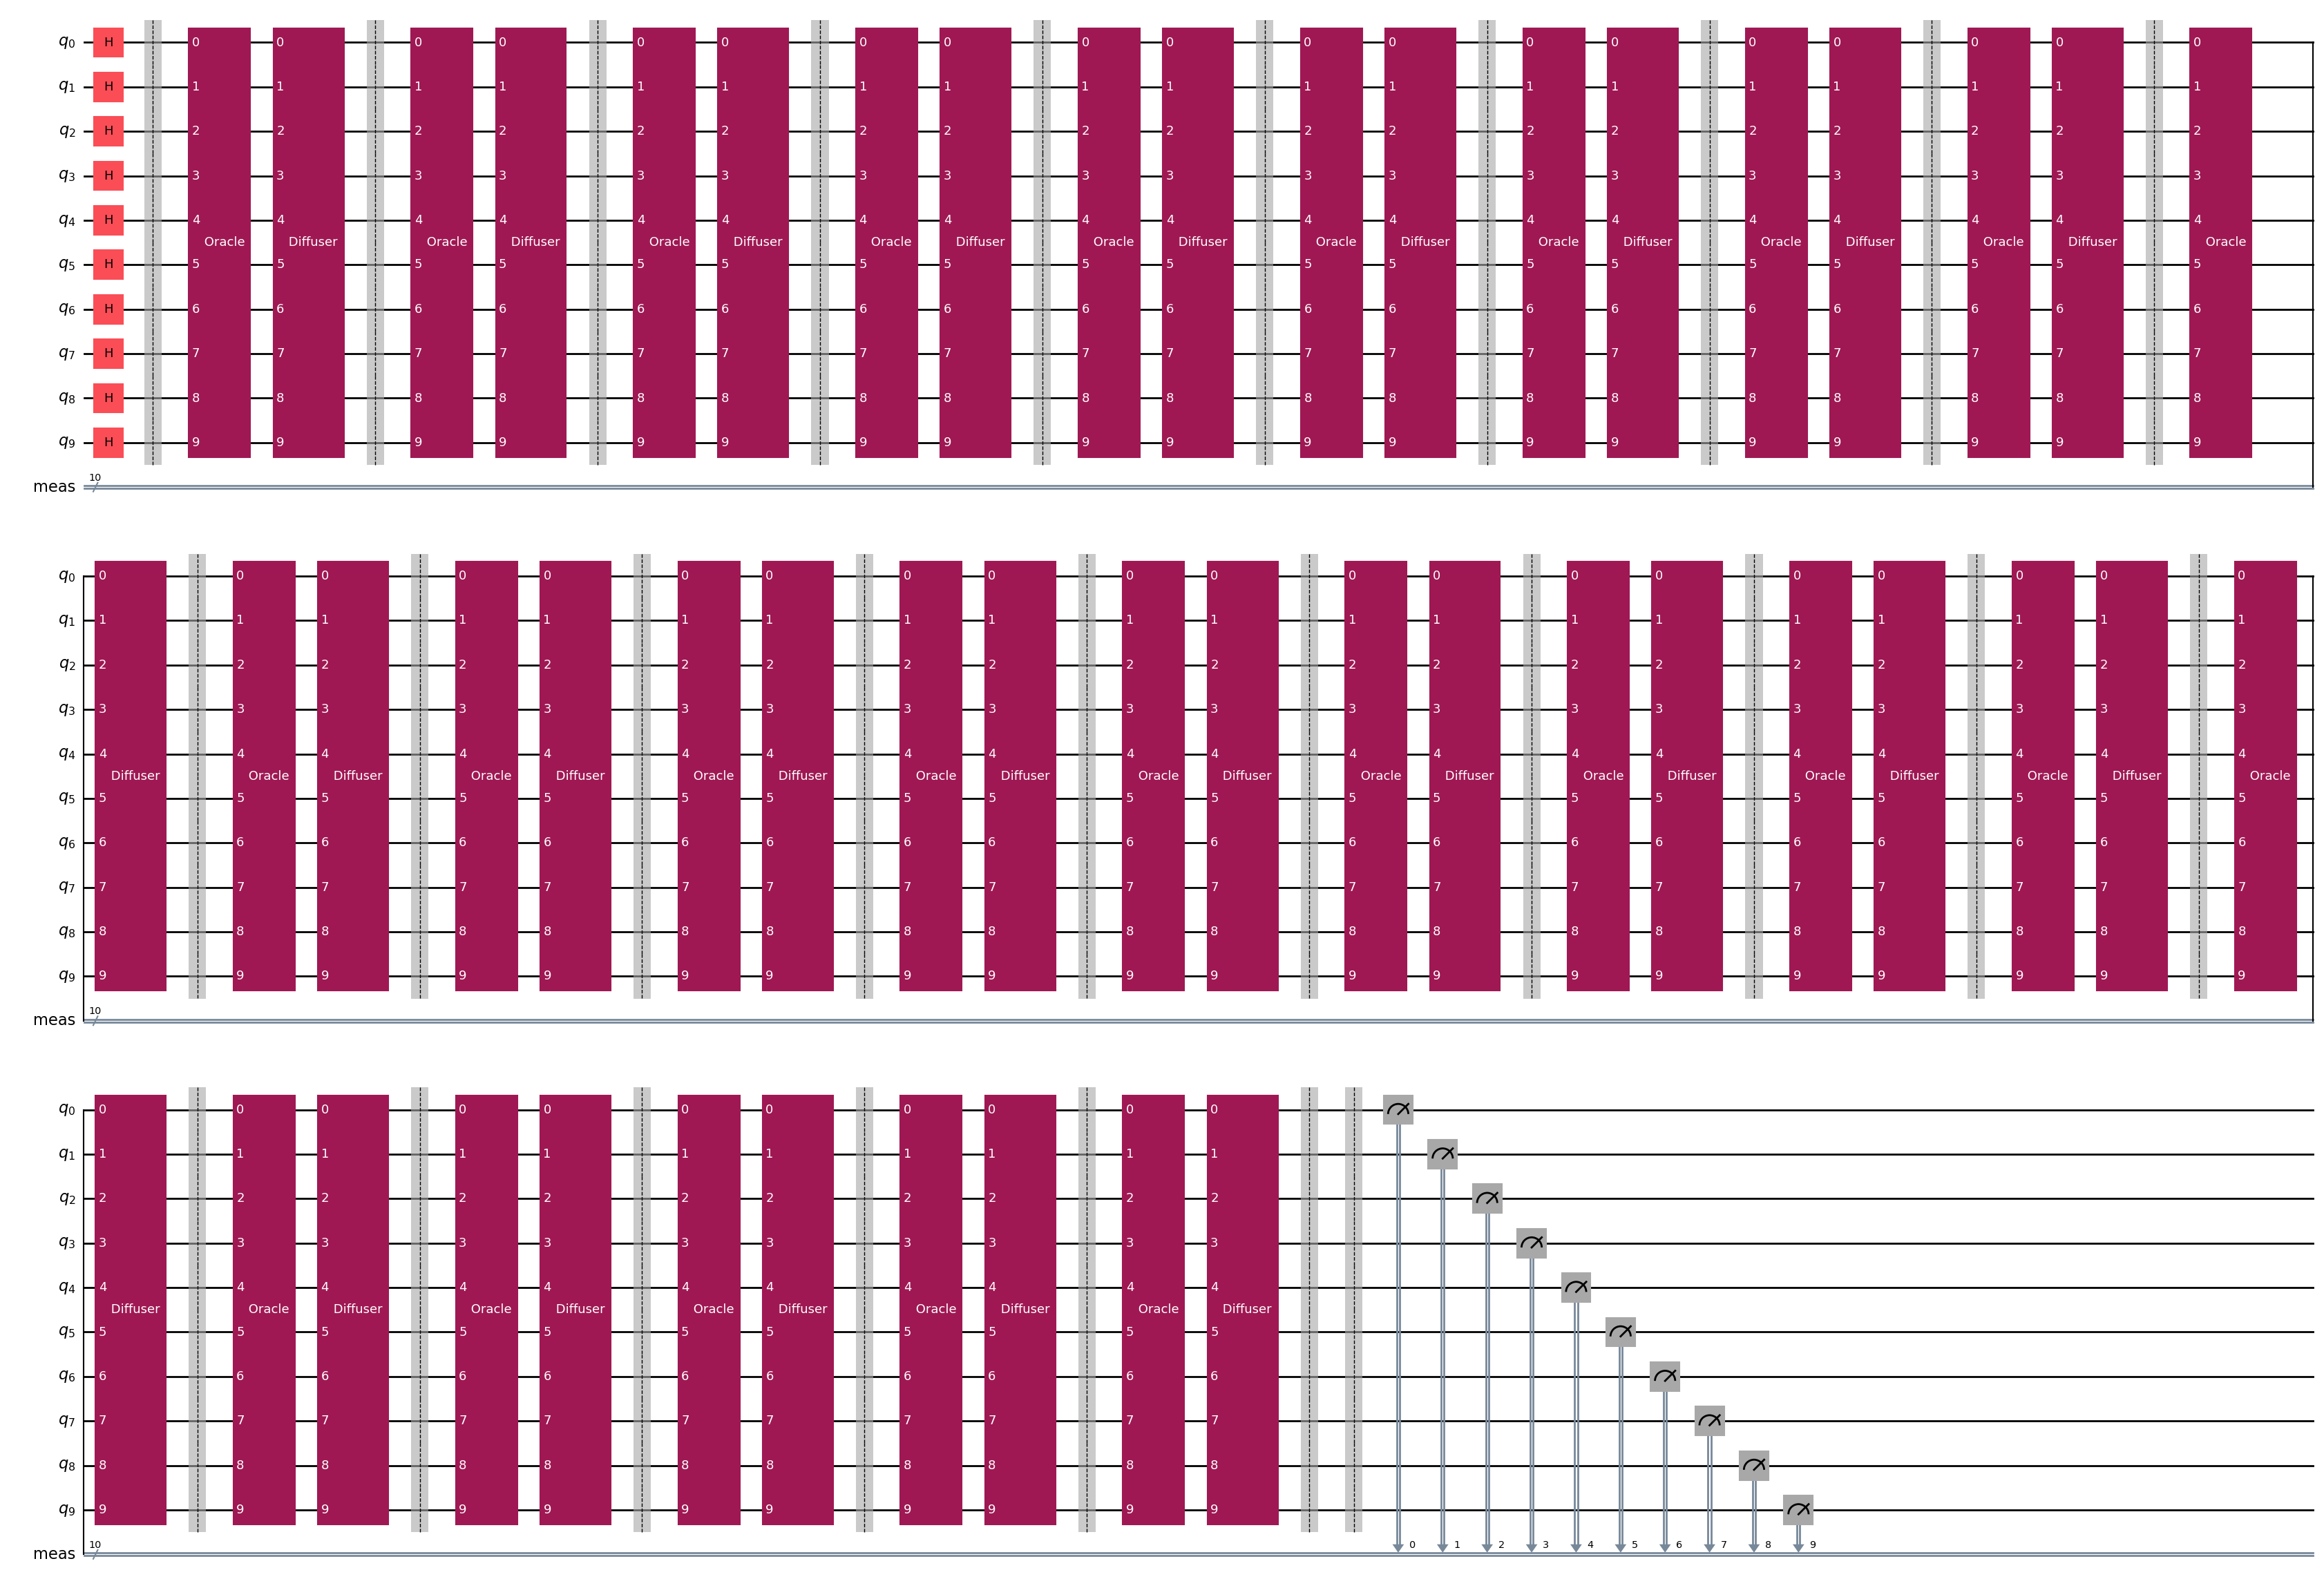

In [9]:
qc.draw('mpl', fold=50)

But, we can even draw the subcircuits themselves to look more closely.

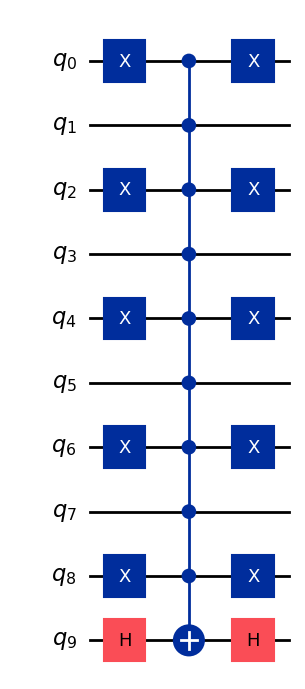

In [10]:
oracle_cicruit.draw('mpl', fold=50)

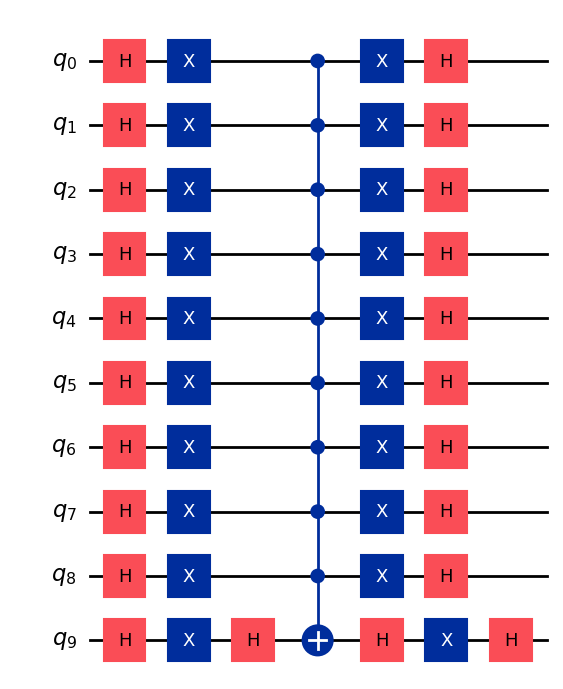

In [11]:
diffuser_circuit.draw('mpl', fold=50)

Well, this is all fun and stuff, but we might acutlly want Grover's to do something useful (as if returning an input with no modificaiton is use enough). So, let's try this with the most classical example, factoring numbers.

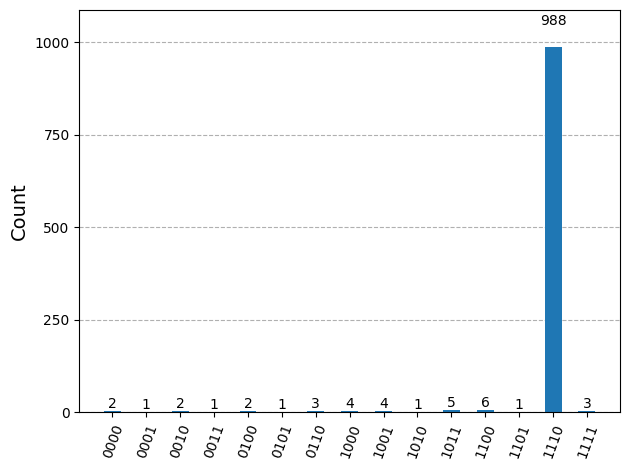

In [24]:
from qiskit import transpile

multiplication_oracle = QuantumCircuit(4, name="Oracle")

multiplication_oracle.x(0) ## specifically target 2 and 3 as our factors of 6
## we will get back to this later
multiplication_oracle.h(3)
multiplication_oracle.mcx([0,1,2], 3)
multiplication_oracle.h(3)
multiplication_oracle.x(0)

oracle_gate = multiplication_oracle.to_gate()

n = 4 ## we will only be using a 4 qubit number here because more qubits is more harder and I am not good enough yet to do the more harder things
qc_factoring = QuantumCircuit(n)

qc_factoring.h(range(n)) ## equal split to start as always

diffuser_circuit = QuantumCircuit(n, name=" Diffuser ") ## creating a gate for the diffuser
diffuser_circuit.h(range(n))
diffuser_circuit.x(range(n))
diffuser_circuit.h(n-1)
diffuser_circuit.mcx(list(range(n-1)), n-1)
diffuser_circuit.h(n-1)
diffuser_circuit.x(range(n))
diffuser_circuit.h(range(n))

diffuser_gate = diffuser_circuit.to_gate()

itterations = int(3.14159 / 4  * math.sqrt(2**n)) ## less itterations because less n (from n=10 to n=4)

for _ in range(itterations):
  qc_factoring.append(oracle_gate, range(n))
  qc_factoring.append(diffuser_gate, range(n))

qc_factoring.measure_all()

transpiled_qc = transpile(qc_factoring, sim) ## unroll the gates I made

## use same sim as before
result = sim.run(transpiled_qc, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

Now I think a good plan would be to look at a real functional oracle rather than a search oracle.

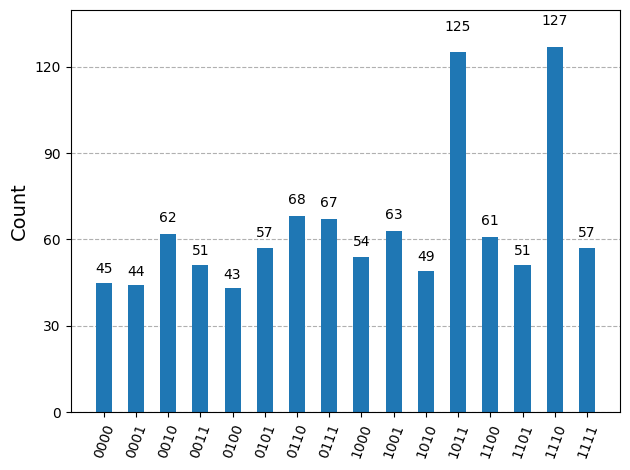

In [28]:
from qiskit import ClassicalRegister

functional_oracle = QuantumCircuit(9, name=" Functional Oracle ")

functional_oracle.ccx(0,2,4)

functional_oracle.ccx(0,3,5)
functional_oracle.ccx(1,2,5)

functional_oracle.ccx(1,3,6)

functional_oracle.x(4)
functional_oracle.x(7)

functional_oracle.h(8)
functional_oracle.mcx([4,5,6,7], 8)
functional_oracle.h(8)

functional_oracle.x(7)
functional_oracle.x(4)

functional_oracle.ccx(1,3,6)
functional_oracle.ccx(1,2,5)
functional_oracle.ccx(0,3,5)
functional_oracle.ccx(0,2,4)

oracle_gate = functional_oracle.to_gate()

## now for the rest of the same things again
n_total = 9
n_search = 4 # We only apply the Diffuser to the search qubits!
qc_factoring = QuantumCircuit(n_total)

qc_factoring.x(8)
qc_factoring.h(8)

qc_factoring.h(range(n_search))
qc_factoring.barrier()

for _ in range(itterations):
    qc_factoring.append(oracle_gate, range(n_total))

    qc_factoring.append(diffuser_gate, range(n_search))
    qc_factoring.barrier()

cr = ClassicalRegister(4)
qc_factoring.add_register(cr)
qc_factoring.measure(range(4), range(4))


transpiled_qc = transpile(qc_factoring, sim) ## unroll the gates I made

## use same sim as before
result = sim.run(transpiled_qc, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

This is all very cool and now we can see that 2\*3 and 3\*2 both equal 6, but we can also see a lot more noise.

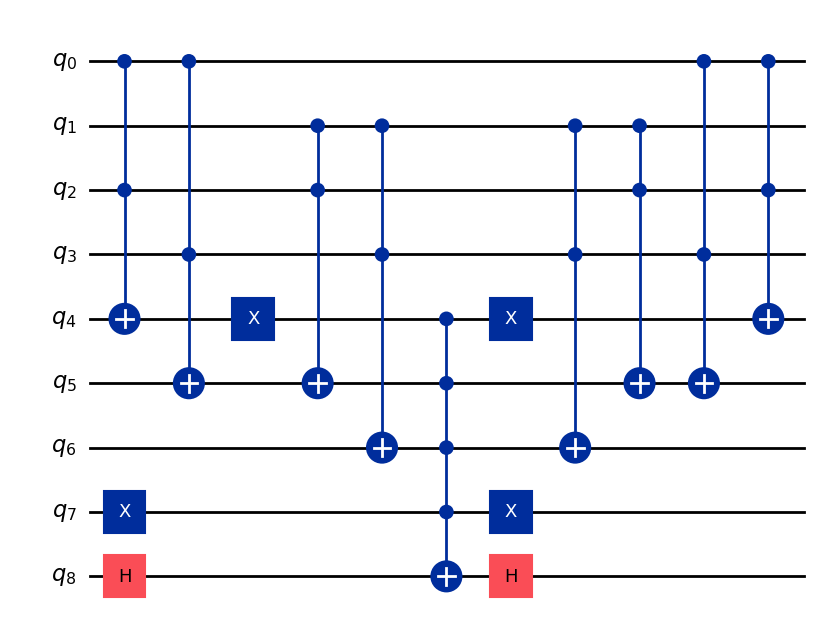

In [30]:
functional_oracle.draw('mpl', fold=50)

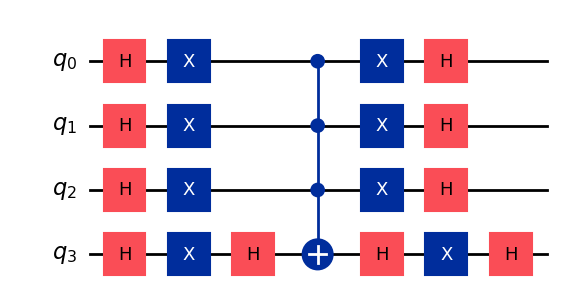

In [29]:
diffuser_circuit.draw('mpl', fold=50)

## Quantum Teleportation
The next topic I want to cover is quantum networking between computers. In order to do so we will gain a bit of understanding of the basics through some elementary examples.